# Linear Attention Vision Transformer (L2ViT) for Particle Mass Regression & Classification

**GSoC 2026 — ML4Sci | Task 2h**

This notebook trains an L2ViT model on CMS detector images to:
- **Classify** particle collision events by heavy particle type
- **Regress** particle mass

Two training regimes are compared:
1. **Pretrain → Finetune**: Self-supervised pretraining on unlabelled data, then finetuned with low LR on labelled data
2. **Scratch**: Same architecture trained from scratch on labelled data only

In [4]:
# Cell 1: Imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

print(f"torch {torch.__version__}")
print(f"cuda  {torch.cuda.is_available()} — "
      f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

torch 2.10.0+cu128
cuda  True — NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# Cell 2: Paths
PROJECT_DIR  = Path(".").resolve()
WEIGHTS_DIR  = PROJECT_DIR / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True)
print(PROJECT_DIR)


/home/gargi/Documents/gsoc/vision_transformer


In [6]:
# Cell 3: Config

# ── Change these per run ──────────────────────────────────────────────────────
MODE          = "finetune"   # "finetune" | "scratch"
UNLABELLED_H5 = PROJECT_DIR / "Dataset_Specific_Unlabelled.h5"
LABELLED_H5   = PROJECT_DIR / "Dataset_Specific_labelled_full_only_for_2i.h5"

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ── Architecture ──────────────────────────────────────────────────────────────
IMG_SIZE    = 125
IN_CHANS    = 8
PATCH_SIZE  = 5          # 125/5 = 25 grid → 625 tokens; each patch = 5×5×8 = 200 raw px
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
EMBED_DIM   = 192        # ViT-Tiny
DEPTH       = 6
NUM_HEADS   = 4
MLP_RATIO   = 4.0
DROP_RATE   = 0.1
NUM_CLASSES = 2

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE      = 96
EPOCHS_PRETRAIN = 40     # 40 epochs on 60k unlabelled samples
EPOCHS_FINETUNE = 40
EPOCHS_SCRATCH  = 40     # matched to EPOCHS_FINETUNE for fair supervised-budget comparison

LR_PRETRAIN  = 3e-4
LR_FINETUNE  = 3e-5
LR_SCRATCH   = 3e-4

WEIGHT_DECAY = 0.05
MASK_RATIO   = 0.75
REG_LAMBDA   = 1.0       # placeholder; overridden by calibrate_lambda() before each run

TEST_FRAC = 0.20
VAL_FRAC  = 0.10

USE_AMP   = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Ablation flag ─────────────────────────────────────────────────────────────
USE_LCM = True   # set False to ablate the Local Concentration Module

# ── Experiment selector ───────────────────────────────────────────────────────
# One of:
#   "l2vit_scratch"        — L²ViT with LCM, supervised only
#   "l2vit_finetune"       — L²ViT with LCM, MAE pretrain → finetune
#   "l2vit_nolcm_scratch"  — L²ViT without LCM (ablation), supervised only
#   "polaformer_scratch"   — PolaFormer, supervised only
#   "polaformer_finetune"  — PolaFormer, MAE pretrain → finetune
#   "vit_scratch"          — VanillaViT (softmax), supervised only  [batch=64, LR scaled]
#   "vit_finetune"         — VanillaViT (softmax), MAE pretrain → finetune  [batch=64, LR scaled]
WANDB_PROJECT = "l2vit-particle"
EXPERIMENT    = "polaformer_scratch"

print(f"EXPERIMENT={EXPERIMENT}  device={DEVICE}  AMP={USE_AMP}  dtype={AMP_DTYPE}")
print(f"labelled   : {LABELLED_H5.name}  (exists={LABELLED_H5.exists()})")
print(f"unlabelled : {UNLABELLED_H5.name}  (exists={UNLABELLED_H5.exists()})")

EXPERIMENT=polaformer_scratch  device=cuda  AMP=True  dtype=torch.bfloat16
labelled   : Dataset_Specific_labelled_full_only_for_2i.h5  (exists=True)
unlabelled : Dataset_Specific_Unlabelled.h5  (exists=True)


In [7]:
# Cell 4: Dataset Loading

with h5py.File(LABELLED_H5, "r") as f:
    _keys       = list(f.keys())
    N, H, W, C  = f["jet"].shape
    _dtype      = f["jet"].dtype
    print(f"jet : {(N,H,W,C)}  dtype={_dtype}  keys={_keys}")

    # full dataset has 'm' (mass) and 'pT'; subset has class label 'Y' only
    if "m" in _keys:
        CLS_KEY, REG_KEY = "Y", "m"
        HAS_REGRESSION   = True
        _y_cls           = f[CLS_KEY][:].flatten().astype(np.int64)
        _reg_raw         = f[REG_KEY][:].flatten().astype(np.float32)
        REG_MIN, REG_MAX = float(_reg_raw.min()), float(_reg_raw.max())
        print(f"Layout: FULL  mass=[{REG_MIN:.2f}, {REG_MAX:.2f}]")
    else:
        CLS_KEY, REG_KEY = "Y", None
        HAS_REGRESSION   = False
        REG_MIN, REG_MAX = 0.0, 1.0
        _y_cls           = f[CLS_KEY][:].flatten().astype(np.int64)
        print("Layout: SUBSET — no mass labels")

DATA_SCALE = 255.0 if np.issubdtype(_dtype, np.integer) else 1.0  # for channel stat calc below

# stratified split preserves class balance across train/val/test
all_idx = np.arange(N)
idx_trainval, idx_test = train_test_split(
    all_idx, test_size=TEST_FRAC, stratify=_y_cls, random_state=SEED)
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=VAL_FRAC / (1.0 - TEST_FRAC),
    stratify=_y_cls[idx_trainval],
    random_state=SEED)

N_TRAIN, N_VAL, N_TEST = len(idx_train), len(idx_val), len(idx_test)
print(f"Split : train={N_TRAIN}  val={N_VAL}  test={N_TEST}  "
      f"(+val={N_TRAIN+N_VAL} = {(N_TRAIN+N_VAL)/N*100:.0f}%)")
print(f"Class balance — train: {(_y_cls[idx_train]==0).sum()}/{(_y_cls[idx_train]==1).sum()}  "
      f"test: {(_y_cls[idx_test]==0).sum()}/{(_y_cls[idx_test]==1).sum()}")

# 200 samples from training set only — never touch val/test for normalization stats
_n_stat   = min(200, N_TRAIN)
_stat_idx = sorted(idx_train[:_n_stat])
with h5py.File(LABELLED_H5, "r") as f:
    _sample = f["jet"][_stat_idx].astype(np.float32) / DATA_SCALE

CHAN_MEAN = _sample.mean(axis=(0, 1, 2)).astype(np.float32)
CHAN_STD  = _sample.std(axis=(0, 1, 2)).clip(min=1e-6).astype(np.float32)
del _sample
print("Channel mean:", np.round(CHAN_MEAN, 3))
print("Channel std :", np.round(CHAN_STD,  3))

if not HAS_REGRESSION:
    REG_LAMBDA = 0.0
    print("REG_LAMBDA = 0 (no mass labels — classification only)")


class JetH5Dataset(Dataset):
    def __init__(self, h5_path, indices=None, labelled=True,
                 cls_key="Y", reg_key=None,
                 reg_min=0.0, reg_max=1.0,
                 chan_mean=None, chan_std=None):
        self.h5_path  = str(h5_path)
        self.labelled = labelled
        self.cls_key  = cls_key
        self.reg_key  = reg_key
        self.reg_min  = reg_min
        self.reg_max  = reg_max
        self._file    = None

        with h5py.File(self.h5_path, "r") as f:
            total = f["jet"].shape[0]
            dtype = f["jet"].dtype
        # detect uint8 vs float32 without assuming — keeps this class self-contained
        self.data_scale = 255.0 if np.issubdtype(dtype, np.integer) else 1.0

        if chan_mean is not None:
            self.mean = torch.from_numpy(chan_mean).view(-1, 1, 1)
            self.std  = torch.from_numpy(chan_std).view(-1, 1, 1)
        else:
            self.mean = self.std = None

        self.indices = list(range(total)) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def _open(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r")

    def __getitem__(self, i):
        self._open()
        idx = self.indices[i]
        img = self._file["jet"][idx].astype(np.float32) / self.data_scale
        x   = torch.from_numpy(img).permute(2, 0, 1)
        if self.mean is not None:
            x = (x - self.mean) / self.std

        if not self.labelled:
            return x

        y_cls = int(self._file[self.cls_key][idx].flat[0])
        if self.reg_key:
            raw   = float(self._file[self.reg_key][idx].flat[0])
            y_reg = (raw - self.reg_min) / (self.reg_max - self.reg_min + 1e-8)
        else:
            y_reg = 0.0
        return (x,
                torch.tensor(y_cls, dtype=torch.long),
                torch.tensor(y_reg, dtype=torch.float32))

    def __getstate__(self):
        # HDF5 file handles can't be pickled; DataLoader forks workers after __init__,
        # so we clear the handle here and let each worker reopen on first __getitem__
        state = self.__dict__.copy()
        state["_file"] = None
        return state


def make_loaders(batch_size=BATCH_SIZE):
    kw = dict(num_workers=4, pin_memory=(DEVICE.type == "cuda"),
              persistent_workers=True)
    def _ds(idx):
        return JetH5Dataset(LABELLED_H5, idx,
                            cls_key=CLS_KEY, reg_key=REG_KEY,
                            reg_min=REG_MIN, reg_max=REG_MAX,
                            chan_mean=CHAN_MEAN, chan_std=CHAN_STD)
    tr = DataLoader(_ds(idx_train), batch_size=batch_size, shuffle=True,  **kw)
    va = DataLoader(_ds(idx_val),   batch_size=batch_size, shuffle=False, **kw)
    te = DataLoader(_ds(idx_test),  batch_size=batch_size, shuffle=False, **kw)
    return tr, va, te


train_loader, val_loader, test_loader = make_loaders()

x, yc, yr = next(iter(train_loader))
print(f"\nBatch: x={tuple(x.shape)}  y_cls={tuple(yc.shape)}  y_reg={tuple(yr.shape)}")
print(f"Pixel range after norm: [{x.min():.2f}, {x.max():.2f}]")
print(f"Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")


jet : (10000, 125, 125, 8)  dtype=float32  keys=['Y', 'jet', 'm', 'pT']
Layout: FULL  mass=[31.95, 728.35]
Split : train=7000  val=1000  test=2000  (+val=8000 = 80%)
Class balance — train: 3586/3414  test: 1024/976
Channel mean: [0.083 0.087 0.057 0.127 1.517 1.187 1.233 1.183]
Channel std : [ 3.157  3.32   2.976  3.289 13.774 12.776 12.342 11.712]

Batch: x=(96, 8, 125, 125)  y_cls=(96,)  y_reg=(96,)
Pixel range after norm: [-0.11, 85.66]
Batches — train:73  val:11  test:21


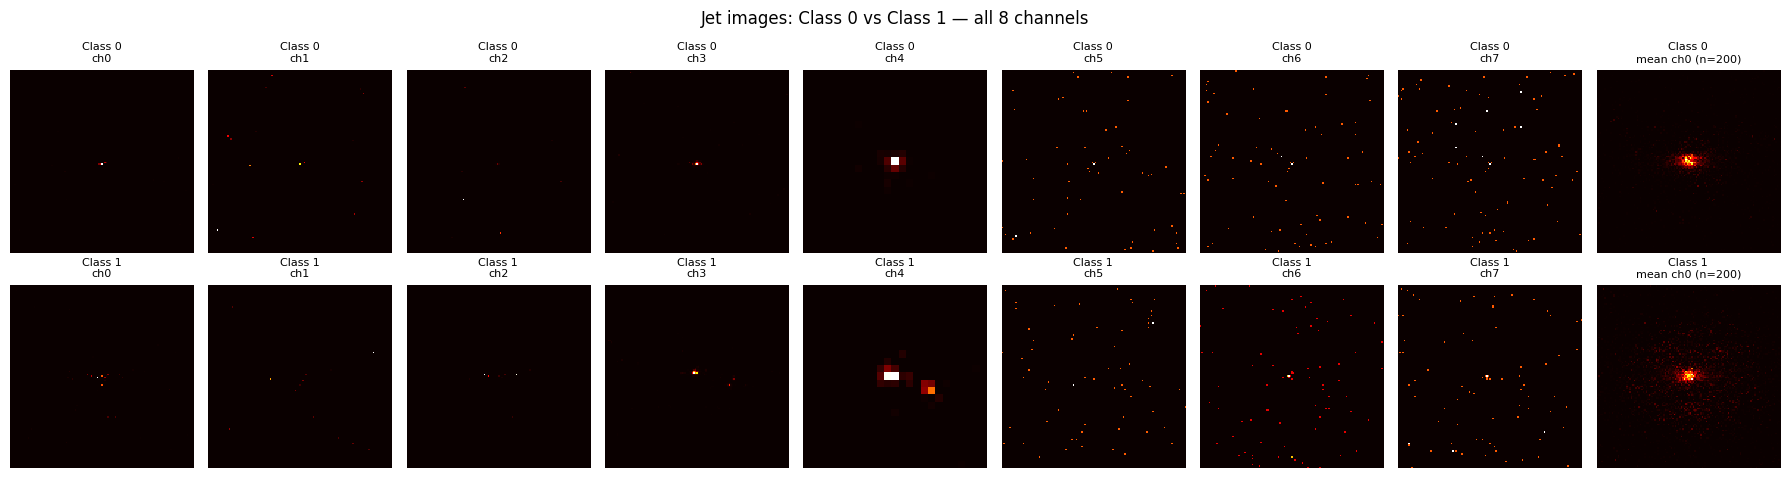

 Ch      mean       std    sparsity
--------------------------------------
  0    0.0827    3.1565       99.7%
  1    0.0873    3.3196       99.8%
  2    0.0573    2.9762       99.9%
  3    0.1275    3.2885       98.5%
  4    1.5167   13.7737       95.3%
  5    1.1873   12.7761       99.2%
  6    1.2328   12.3417       99.0%
  7    1.1834   11.7120       99.0%


In [8]:
# Cell 5: EDA — Jet Image Visualization

with h5py.File(LABELLED_H5, "r") as f:
    _y    = f[CLS_KEY][:].flatten().astype(np.int64)
    _i0   = np.where(_y == 0)[0][:200]
    _i1   = np.where(_y == 1)[0][:200]
    _ex0  = f["jet"][_i0[0]].astype(np.float32) / DATA_SCALE
    _ex1  = f["jet"][_i1[0]].astype(np.float32) / DATA_SCALE
    _m0   = f["jet"][sorted(_i0)].astype(np.float32).mean(0) / DATA_SCALE
    _m1   = f["jet"][sorted(_i1)].astype(np.float32).mean(0) / DATA_SCALE
    # 200 samples (100 per class) for sparsity — fraction of exact zero pixels
    _samp = f["jet"][sorted(np.concatenate([_i0[:100], _i1[:100]]).tolist())
                    ].astype(np.float32) / DATA_SCALE

sparsity = (_samp == 0).mean(axis=(0, 1, 2))   # (C,) — true zero fraction
del _samp

# all 8 channels for a single example per class, plus per-class mean (ch0)
fig, axes = plt.subplots(2, C + 1, figsize=(18, 5))
for row, (ex, mean_img, label) in enumerate([
        (_ex0, _m0, "Class 0"), (_ex1, _m1, "Class 1")]):
    for ch in range(C):
        axes[row, ch].imshow(ex[:, :, ch], cmap="hot", interpolation="nearest")
        axes[row, ch].set_title(f"{label}\nch{ch}", fontsize=8)
        axes[row, ch].axis("off")
    axes[row, -1].imshow(mean_img[:, :, 0], cmap="hot", interpolation="nearest")
    axes[row, -1].set_title(f"{label}\nmean ch0 (n=200)", fontsize=8)
    axes[row, -1].axis("off")

plt.suptitle("Jet images: Class 0 vs Class 1 — all 8 channels", fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "jet_eda.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"{'Ch':>3}  {'mean':>8}  {'std':>8}  {'sparsity':>10}")
print("-" * 38)
for ch in range(C):
    print(f"{ch:>3}  {CHAN_MEAN[ch]:>8.4f}  {CHAN_STD[ch]:>8.4f}  {sparsity[ch]*100:>9.1f}%")


In [9]:
# Cell 6: L2ViT Architecture
# arXiv:2501.16182  |  github.com/ChuanyangZheng/L2ViT


class PatchEmbed(nn.Module):
    def __init__(self, img_size=125, patch_size=5, in_chans=8, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.grid_size   = img_size // patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.proj(x).flatten(2).transpose(1, 2))


class LinearAttention(nn.Module):
    # Linear-complexity attention from L2ViT.
    # Feature map φ(x) = ReLU(x) keeps Q, K non-negative, which lets us use the
    # associativity of matrix products: φ(Q)(φ(K)ᵀV) costs O(ND²) vs O(N²D)
    # for standard dot-product attention. No approximation — exact for this φ.
    # Denominator φ(q_n)·Σφ(k) normalises each token's output.
    # Clamped at 1e-2 so outputs don't explode when both q and k are near-zero post-ReLU.

    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        # one learnable scale per head — heads specialise at different magnitudes
        self.scale = nn.Parameter(
            torch.full((num_heads, 1, 1), self.head_dim ** 0.5))
        self.qkv  = nn.Linear(dim, 3 * dim, bias=False)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        H, D    = self.num_heads, self.head_dim
        qkv     = self.qkv(x).reshape(B, N, 3, H, D).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)                    # (B, H, N, D)

        q = F.relu(q) * self.scale
        k = F.relu(k)

        kv    = k.transpose(-2, -1) @ v            # (B, H, D, D) — precomputed context
        num   = q @ kv                             # (B, H, N, D)
        denom = (q * k.sum(dim=2, keepdim=True)).sum(-1, keepdim=True).clamp(1e-2)
        out   = (num / denom).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class PolarityLinearAttention(nn.Module):
    """Polarity-aware linear attention (PolaFormer, Meng et al. ICLR 2025).

    Standard linear attention applies ReLU as feature map φ, which clips
    negative Q·K interactions to zero. This raises attention entropy and
    reduces discriminability. PolaFormer instead writes:

        φ(x) = [ReLU(x), ReLU(-x)]   (dimension doubles to 2D)

    so both positive and negative components of the projection are
    preserved. The context matrix is then:

        KV = φ(K)ᵀ V   shape (B, H, 2D, D)

    and each query attends via:

        out_n = φ(q_n) @ KV / (φ(q_n) @ Σφ(k))

    This is still O(ND²) — no quadratic term — because the 2D expansion
    is in the head dimension, not the sequence dimension.

    The denominator clamp prevents division by near-zero values when a
    token's projection is entirely in one polarity hemisphere.
    """

    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        # scale applied after feature map — same role as in LinearAttention
        self.scale = nn.Parameter(
            torch.full((num_heads, 1, 1), float(self.head_dim) ** 0.5))
        self.qkv  = nn.Linear(dim, 3 * dim, bias=False)
        self.proj = nn.Linear(dim, dim)

    @staticmethod
    def _phi(x: torch.Tensor) -> torch.Tensor:
        """Feature map: φ(x) = [ReLU(x), ReLU(-x)], doubles last dim."""
        return torch.cat([F.relu(x), F.relu(-x)], dim=-1)   # (..., 2D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        H, D    = self.num_heads, self.head_dim

        qkv = self.qkv(x).reshape(B, N, 3, H, D).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)                              # (B, H, N, D)

        q = self._phi(q) * self.scale                        # (B, H, N, 2D)
        k = self._phi(k)                                     # (B, H, N, 2D)

        # context matrix: (B, H, 2D, D) — built once for all queries
        kv    = k.transpose(-2, -1) @ v                      # (B, H, 2D, D)

        # numerator: each query reads from the shared context
        num   = q @ kv                                       # (B, H, N, D)

        # denominator: sum of key feature maps, broadcast over N queries
        k_sum = k.sum(dim=2, keepdim=True)                   # (B, H, 1, 2D)
        denom = (q * k_sum).sum(dim=-1, keepdim=True)        # (B, H, N, 1)
        denom = denom.clamp(min=1e-2)

        out = (num / denom).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class PolaFormerBlock(nn.Module):
    """Transformer block using PolarityLinearAttention instead of LinearAttention.

    LCM is retained so the comparison is fair: both L²ViT and PolaFormer
    use the same local concentration strategy. The variable under test is
    exclusively the attention kernel (ReLU vs polarity-aware).

    To ablate LCM for PolaFormer as well, pass use_lcm=False.
    """

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0,
                 drop: float = 0.0, grid_size: int = 25, use_lcm: bool = True):
        super().__init__()
        self.use_lcm  = use_lcm
        self.norm1    = nn.LayerNorm(dim)
        self.attn     = PolarityLinearAttention(dim, num_heads)
        self.norm2    = nn.LayerNorm(dim)
        self.mlp      = MLP(dim, mlp_ratio, drop)
        if use_lcm:
            self.norm_lcm = nn.LayerNorm(dim)
            self.lcm      = LCM(dim, grid_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        if self.use_lcm:
            x = x + self.lcm(self.norm_lcm(x))
        x = x + self.mlp(self.norm2(x))
        return x


class LCM(nn.Module):
    # Local Concentration Module from L2ViT.
    # Linear attention is permutation-invariant and loses local spatial structure.
    # LCM reintroduces it: patch tokens are reshaped back to the 2D grid, then two
    # 7×7 depthwise convolutions capture a 35-pixel receptive field at patch resolution.
    # Output is added residually so the module can become a no-op on channels
    # where global context already suffices.
    # GroupNorm not BatchNorm: BN running stats computed during MAE pretraining
    # are stale at finetuning time (different data distribution and batch size).

    def __init__(self, dim, grid_size=25):
        super().__init__()
        self.grid_size = grid_size
        n_groups = min(32, dim)
        self.dw1  = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.gn1  = nn.GroupNorm(n_groups, dim)
        self.dw2  = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.gn2  = nn.GroupNorm(n_groups, dim)
        self.proj = nn.Linear(dim, dim)
        self.act  = nn.GELU()

    def forward(self, x):
        B, N1, D = x.shape
        cls     = x[:, :1]          # CLS token bypasses spatial ops
        patches = x[:, 1:]
        g       = self.grid_size

        h = patches.transpose(1, 2).reshape(B, D, g, g)
        h = self.act(self.gn1(self.dw1(h)))
        h = self.act(self.gn2(self.dw2(h)))
        h = h.reshape(B, D, g * g).transpose(1, 2)
        return torch.cat([cls, patches + self.proj(h)], dim=1)


class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))

    def forward(self, x):
        return self.net(x)


class L2ViTBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.0,
                 grid_size=25, use_lcm=True):
        super().__init__()
        self.use_lcm  = use_lcm
        self.norm1    = nn.LayerNorm(dim)
        self.attn     = LinearAttention(dim, num_heads)
        self.norm2    = nn.LayerNorm(dim)
        self.mlp      = MLP(dim, mlp_ratio, drop)
        if use_lcm:
            self.norm_lcm = nn.LayerNorm(dim)
            self.lcm      = LCM(dim, grid_size)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        if self.use_lcm:
            x = x + self.lcm(self.norm_lcm(x))
        x = x + self.mlp(self.norm2(x))
        return x


class L2ViTEncoder(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS,
                 embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
                 mlp_ratio=MLP_RATIO, drop_rate=DROP_RATE, use_lcm=True):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n         = self.patch_embed.num_patches
        grid_size = self.patch_embed.grid_size

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        self.pos_drop  = nn.Dropout(drop_rate)
        self.blocks    = nn.ModuleList([
            L2ViTBlock(embed_dim, num_heads, mlp_ratio, drop_rate,
                       grid_size, use_lcm=use_lcm)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        # std=0.02 from BERT (Devlin et al., 2019) — keeps initial activations small
        # so residual streams don't saturate before the first gradient update
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x   = self.patch_embed(x)
        B   = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)


class PolaFormerEncoder(nn.Module):
    """PolaFormer encoder — same hyperparameters as L2ViTEncoder,
    PolarityLinearAttention in place of LinearAttention."""

    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS,
                 embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
                 mlp_ratio=MLP_RATIO, drop_rate=DROP_RATE, use_lcm=True):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n         = self.patch_embed.num_patches
        grid_size = self.patch_embed.grid_size

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        self.pos_drop  = nn.Dropout(drop_rate)
        self.blocks    = nn.ModuleList([
            PolaFormerBlock(embed_dim, num_heads, mlp_ratio, drop_rate,
                            grid_size, use_lcm=use_lcm)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x   = self.patch_embed(x)
        B   = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)


class VanillaAttention(nn.Module):
    """Standard scaled dot-product attention (Vaswani et al., 2017).
    O(N²) in sequence length. Used only as quality baseline — not for
    deployment at detector scale."""

    def __init__(self, dim: int, num_heads: int = 4, drop: float = 0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, 3 * dim, bias=False)
        self.proj      = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        H, D    = self.num_heads, self.head_dim
        qkv = self.qkv(x).reshape(B, N, 3, H, D).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        out  = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class VanillaViTBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0,
                 drop: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = VanillaAttention(dim, num_heads, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VanillaViTEncoder(nn.Module):
    """Softmax ViT encoder — same hyperparameters as L2ViTEncoder.
    No LCM. Quality upper-bound baseline."""

    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS,
                 embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
                 mlp_ratio=MLP_RATIO, drop_rate=DROP_RATE):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        self.pos_drop  = nn.Dropout(drop_rate)
        self.blocks    = nn.ModuleList([
            VanillaViTBlock(embed_dim, num_heads, mlp_ratio, drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x   = self.patch_embed(x)
        B   = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)


class L2ViTDualHead(nn.Module):
    # Shared encoder; CLS token feeds two independent heads.
    # Classification: cross-entropy over NUM_CLASSES
    # Regression: MSE on normalised mass in [0, 1]

    def __init__(self, encoder, num_classes=NUM_CLASSES, drop=DROP_RATE):
        super().__init__()
        self.encoder  = encoder
        d = encoder.norm.normalized_shape[0]
        self.cls_head = nn.Sequential(nn.Dropout(drop), nn.Linear(d, num_classes))
        self.reg_head = nn.Sequential(nn.Dropout(drop), nn.Linear(d, 1))

    def forward(self, x):
        t = self.encoder(x)[:, 0]
        return self.cls_head(t), self.reg_head(t).squeeze(-1)


class MAE(nn.Module):
    # Masked autoencoder pretraining (He et al., 2022).
    # BEiT-style: masked positions are replaced with a learned mask_token rather
    # than dropped. We cannot drop tokens because LCM.forward() reshapes the
    # patch sequence to the full 25×25 grid — any missing tokens would corrupt
    # that reshape. Loss is MSE on masked patches only; including visible patches
    # would make the task trivially easy.

    def __init__(self, encoder, patch_size=PATCH_SIZE, in_chans=IN_CHANS,
                 decoder_dim=128, mask_ratio=MASK_RATIO):
        super().__init__()
        self.encoder    = encoder
        self.patch_size = patch_size
        self.in_chans   = in_chans
        self.mask_ratio = mask_ratio
        embed_dim       = encoder.norm.normalized_shape[0]
        patch_pixels    = patch_size * patch_size * in_chans

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder    = nn.Sequential(
            nn.Linear(embed_dim, decoder_dim), nn.GELU(),
            nn.Linear(decoder_dim, patch_pixels))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def _random_mask(self, B: int, N: int, device: torch.device,
                     patch_energy: torch.Tensor | None = None) -> torch.Tensor:
        """Return a boolean mask of shape (B, N), True = masked.

        If patch_energy is provided (shape B×N, non-negative), patches are
        sampled with probability proportional to their energy so that
        high-energy (signal-rich) patches are masked more often.
        This forces the encoder to reconstruct physically meaningful structure
        rather than trivially predicting zeros for empty patches.

        When patch_energy is None the method falls back to uniform random
        masking (used during inference / shape checks where raw images are
        not available).
        """
        n_mask = int(N * self.mask_ratio)

        if patch_energy is None:
            # uniform fallback — same behaviour as original code
            noise = torch.rand(B, N, device=device)
        else:
            # energy is non-negative; add small epsilon for numerical safety
            # higher energy → higher sampling weight → more likely to be masked
            eps   = 1e-6
            w     = patch_energy.float() + eps          # (B, N)
            w     = w / w.sum(dim=1, keepdim=True)      # normalise to simplex
            # gumbel trick: -log(-log(u)) / w is equivalent to weighted sampling
            # without replacement; argsort gives the selection order
            u     = torch.rand(B, N, device=device).clamp(min=eps)
            noise = -torch.log(-torch.log(u)) / w       # (B, N)

        # argsort: smallest noise values → first n_mask indices → masked
        # (for uniform noise this is a uniform shuffle; for weighted noise
        # high-energy patches cluster at the front)
        ids_shuffle = noise.argsort(dim=1, descending=True)   # high noise first
        mask        = torch.zeros(B, N, dtype=torch.bool, device=device)
        mask.scatter_(1, ids_shuffle[:, :n_mask], True)
        return mask

    def _patchify(self, x):
        p = self.patch_size
        B, C, H, W = x.shape
        h, w = H // p, W // p
        return (x.reshape(B, C, h, p, w, p)
                  .permute(0, 2, 4, 1, 3, 5)
                  .reshape(B, h * w, C * p * p))

    def forward(self, x: torch.Tensor):
        enc  = self.encoder
        B, N = x.size(0), enc.patch_embed.num_patches

        # compute per-patch L1 energy from raw image BEFORE embedding
        # patchify gives (B, N, C*p*p); sum of absolute values = energy proxy
        with torch.no_grad():
            patches_raw  = self._patchify(x)                   # (B, N, C*p*p)
            patch_energy = patches_raw.abs().sum(dim=-1)        # (B, N)

        tokens = enc.patch_embed(x)                             # (B, N, D)
        mask   = self._random_mask(B, N, x.device, patch_energy)

        # BEiT-style: replace masked positions with learned mask_token
        # (cannot drop tokens — LCM reshapes to full 25×25 grid)
        tokens = torch.where(mask.unsqueeze(-1),
                             self.mask_token.expand(B, N, -1), tokens)

        cls    = enc.cls_token.expand(B, -1, -1)
        tokens = enc.pos_drop(torch.cat([cls, tokens], dim=1) + enc.pos_embed)
        for blk in enc.blocks:
            tokens = blk(tokens)
        tokens = enc.norm(tokens)

        pred   = self.decoder(tokens[:, 1:])
        target = self._patchify(x)
        loss   = F.mse_loss(pred[mask], target[mask])
        return loss, mask


# sanity-check shapes before any training
for _name, _EncCls, _kw in [
    ("VanillaViT",         VanillaViTEncoder,  {}),
    ("L2ViT (with LCM)",   L2ViTEncoder,       {"use_lcm": True}),
    ("L2ViT (no LCM)",     L2ViTEncoder,       {"use_lcm": False}),
    ("PolaFormer",         PolaFormerEncoder,  {"use_lcm": True}),
]:
    _enc  = _EncCls(**_kw).to(DEVICE)
    _dual = L2ViTDualHead(_enc).to(DEVICE)
    _mae  = MAE(_enc).to(DEVICE)
    _d    = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE, device=DEVICE)
    with torch.no_grad():
        _cl, _ro = _dual(_d)
        _ml, _   = _mae(_d)
    n_params = sum(p.numel() for p in _enc.parameters()) / 1e6
    print(f"{_name:<22}  cls={tuple(_cl.shape)}  reg={tuple(_ro.shape)}  "
          f"MAE_loss={_ml.item():.4f}  params={n_params:.2f}M")
    del _enc, _dual, _mae, _d


VanillaViT              cls=(2, 2)  reg=(2,)  MAE_loss=0.0523  params=2.83M
L2ViT (with LCM)        cls=(2, 2)  reg=(2,)  MAE_loss=0.0356  params=3.17M
L2ViT (no LCM)          cls=(2, 2)  reg=(2,)  MAE_loss=0.0440  params=2.83M
PolaFormer              cls=(2, 2)  reg=(2,)  MAE_loss=0.0392  params=3.17M


In [10]:
# Cell 7: Training Utilities
import wandb
from torch.optim.lr_scheduler import CosineAnnealingLR


def cosine_scheduler(optimizer, epochs, warmup=5, eta_min=1e-6):
    # linear warmup then cosine decay
    warmup_sched = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda e: (e + 1) / warmup if e < warmup else 1.0)
    cosine_sched = CosineAnnealingLR(
        optimizer, T_max=max(1, epochs - warmup), eta_min=eta_min)
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, [warmup_sched, cosine_sched], milestones=[warmup])


def dual_loss(cls_logits, reg_out, y_cls, y_reg, lam=None):
    if lam is None:
        lam = REG_LAMBDA
    cls_loss = F.cross_entropy(cls_logits, y_cls)
    reg_loss = F.l1_loss(reg_out, y_reg)
    return cls_loss + lam * reg_loss, cls_loss.item(), reg_loss.item()


def calibrate_lambda(model, loader, device, n_batches=5):
    # set lambda = CE/MSE so both loss terms start at equal scale
    if not HAS_REGRESSION:
        return 0.0
    model.eval()
    ce_vals, mse_vals = [], []
    with torch.no_grad():
        for i, (x, yc, yr) in enumerate(loader):
            if i >= n_batches: break
            x, yc, yr = x.to(device), yc.to(device), yr.to(device)
            with autocast(device.type, enabled=USE_AMP, dtype=AMP_DTYPE):
                cl, ro = model(x)
            ce_vals.append(F.cross_entropy(cl, yc).item())
            mse_vals.append(F.mse_loss(ro, yr).item())
    mean_ce  = float(np.mean(ce_vals))
    mean_mse = float(np.mean(mse_vals))
    lam      = mean_ce / max(mean_mse, 1e-8)
    print(f"Auto REG_LAMBDA = {lam:.3f}  (CE={mean_ce:.4f}, MSE={mean_mse:.4f})")
    return lam


def train_epoch(model, loader, optimizer, device=DEVICE, lam=None):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y_cls, y_reg in loader:
        x, y_cls, y_reg = x.to(device), y_cls.to(device), y_reg.to(device)
        optimizer.zero_grad()
        with autocast(device.type, enabled=USE_AMP, dtype=AMP_DTYPE):
            cls_logits, reg_out = model(x)
            loss, _, _ = dual_loss(cls_logits, reg_out, y_cls, y_reg, lam=lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # standard ViT clip
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (cls_logits.argmax(1) == y_cls).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, device=DEVICE, lam=None):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y_cls, y_reg in loader:
        x, y_cls, y_reg = x.to(device), y_cls.to(device), y_reg.to(device)
        with autocast(device.type, enabled=USE_AMP, dtype=AMP_DTYPE):
            cls_logits, reg_out = model(x)
            loss, _, _ = dual_loss(cls_logits, reg_out, y_cls, y_reg, lam=lam)
        total_loss += loss.item() * x.size(0)
        correct    += (cls_logits.argmax(1) == y_cls).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


def run_supervised(model, train_loader, val_loader, epochs, lr,
                   weight_decay=WEIGHT_DECAY, label="model",
                   device=DEVICE, save_path=None,
                   freeze_epochs=0):
    """
    freeze_epochs: int
        Number of initial epochs during which encoder parameters are frozen.
        Set to 0 (default) for scratch training.
        Recommended: 10 for pretrain→finetune runs.
    """
    lam = calibrate_lambda(model, train_loader, device)

    decay    = [p for n, p in model.named_parameters() if p.ndim >= 2]
    no_decay = [p for n, p in model.named_parameters() if p.ndim < 2]
    optimizer = torch.optim.AdamW(
        [{"params": decay,    "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr)
    scheduler = cosine_scheduler(optimizer, epochs)

    history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # freeze encoder if requested — only the .encoder sub-module is frozen;
    # task heads always receive gradients
    def _set_encoder_grad(requires_grad: bool):
        if hasattr(model, "encoder"):
            for p in model.encoder.parameters():
                p.requires_grad = requires_grad

    if freeze_epochs > 0:
        _set_encoder_grad(False)
        print(f"{label}: encoder frozen for first {freeze_epochs} epochs")

    bar = tqdm(range(1, epochs + 1), desc=label)
    for epoch in bar:
        # unfreeze encoder after freeze_epochs
        if freeze_epochs > 0 and epoch == freeze_epochs + 1:
            _set_encoder_grad(True)
            print(f"\n{label}: encoder unfrozen at epoch {epoch}")

        tl, ta = train_epoch(model, train_loader, optimizer, device, lam=lam)
        vl, va = evaluate(model, val_loader, device, lam=lam)
        scheduler.step()

        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        lr_now = scheduler.get_last_lr()[0]
        bar.set_postfix(tr=f"{ta:.3f}", val=f"{va:.3f}",
                        lr=f"{lr_now:.1e}")
        wandb.log({"train_loss": tl, "train_acc": ta,
                   "val_loss": vl,   "val_acc": va,
                   "lr": lr_now, "epoch": epoch})

    model.load_state_dict(best_state)
    if save_path:
        torch.save(best_state, save_path)
        print(f"saved → {save_path}")
    print(f"{label}  best val-acc = {best_val_acc:.4f}")
    return history


In [8]:
# Cell 9: Run experiment

def build_encoder(experiment: str):
    """Return a freshly initialised encoder for the given experiment key."""
    if experiment in ("vit_scratch", "vit_finetune"):
        return VanillaViTEncoder().to(DEVICE)
    elif experiment in ("l2vit_scratch", "l2vit_finetune"):
        return L2ViTEncoder(use_lcm=True).to(DEVICE)
    elif experiment == "l2vit_nolcm_scratch":
        return L2ViTEncoder(use_lcm=False).to(DEVICE)
    elif experiment in ("polaformer_scratch", "polaformer_finetune"):
        return PolaFormerEncoder(use_lcm=True).to(DEVICE)
    else:
        raise ValueError(f"Unknown experiment: {experiment!r}")


def run_mae_pretrain(encoder, save_path: Path) -> None:
    """Pretrain encoder with energy-weighted MAE on unlabelled data.
    Saves best encoder weights to save_path."""
    unlabelled_ds   = JetH5Dataset(UNLABELLED_H5, labelled=False,
                                   chan_mean=CHAN_MEAN, chan_std=CHAN_STD)
    pretrain_loader = DataLoader(
        unlabelled_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=True)
    print(f"Unlabelled: {len(unlabelled_ds):,} samples  |  "
          f"{len(pretrain_loader)} batches/epoch")

    mae_model = MAE(encoder).to(DEVICE)

    decay    = [p for n, p in mae_model.named_parameters() if p.ndim >= 2]
    no_decay = [p for n, p in mae_model.named_parameters() if p.ndim < 2]
    opt = torch.optim.AdamW(
        [{"params": decay,    "weight_decay": WEIGHT_DECAY},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=LR_PRETRAIN)
    sched = cosine_scheduler(opt, EPOCHS_PRETRAIN, warmup=3)

    best_loss, best_state = float("inf"), None
    log_path = PROJECT_DIR / f"pretrain_{EXPERIMENT}.csv"
    with open(log_path, "w") as f:
        f.write("epoch,loss,lr\n")

    epoch_bar = tqdm(range(1, EPOCHS_PRETRAIN + 1), desc=f"MAE {EXPERIMENT}")
    for epoch in epoch_bar:
        mae_model.train()
        total = 0.0
        batch_bar = tqdm(pretrain_loader, desc=f"  ep{epoch:03d}", leave=False,
                         unit="batch", dynamic_ncols=True)
        for x in batch_bar:
            x = x.to(DEVICE)
            opt.zero_grad()
            with autocast(DEVICE.type, enabled=USE_AMP, dtype=AMP_DTYPE):
                loss, _ = mae_model(x)
            loss.backward()
            nn.utils.clip_grad_norm_(mae_model.parameters(), 1.0)
            opt.step()
            total += loss.item() * x.size(0)
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        ep_loss = total / len(unlabelled_ds)
        sched.step()
        lr_now = sched.get_last_lr()[0]
        improved = "✓" if ep_loss < best_loss else " "
        epoch_bar.set_postfix(loss=f"{ep_loss:.4f}", lr=f"{lr_now:.1e}", best=f"{best_loss:.4f}")
        print(f"  [{improved}] epoch {epoch:03d}/{EPOCHS_PRETRAIN}  loss={ep_loss:.4f}  lr={lr_now:.2e}  best={best_loss:.4f}")
        with open(log_path, "a") as f:
            f.write(f"{epoch},{ep_loss:.6f},{lr_now:.2e}\n")
        wandb.log({"pretrain_loss": ep_loss, "pretrain_lr": lr_now, "pretrain_epoch": epoch})
        if ep_loss < best_loss:
            best_loss  = ep_loss
            best_state = {k: v.cpu().clone()
                          for k, v in encoder.state_dict().items()}

    encoder.load_state_dict(best_state)
    torch.save(best_state, save_path)
    print(f"Best MAE loss = {best_loss:.4f}  →  saved {save_path.name}")


# ── Build and run ─────────────────────────────────────────────────────────────
WANDB_PROJECT = globals().get("WANDB_PROJECT", "l2vit-particle")
wandb.init(project=WANDB_PROJECT, name=EXPERIMENT, reinit=True,
           config=dict(experiment=EXPERIMENT, epochs_pretrain=EPOCHS_PRETRAIN,
                       epochs_supervised=EPOCHS_FINETUNE if EXPERIMENT.endswith('_finetune') else EPOCHS_SCRATCH,
                       lr_pretrain=LR_PRETRAIN, lr_finetune=LR_FINETUNE,
                       lr_scratch=LR_SCRATCH, mask_ratio=MASK_RATIO,
                       embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS))

encoder   = build_encoder(EXPERIMENT)
model     = L2ViTDualHead(encoder).to(DEVICE)
is_ft     = EXPERIMENT.endswith("_finetune")
ckpt_name = f"model_{EXPERIMENT}.pt"

if is_ft:
    enc_ckpt = WEIGHTS_DIR / f"encoder_{EXPERIMENT}.pt"
    if enc_ckpt.exists():
        print(f"Loading cached encoder from {enc_ckpt.name}")
        encoder.load_state_dict(torch.load(enc_ckpt, map_location=DEVICE))
    else:
        run_mae_pretrain(encoder, enc_ckpt)

hist = run_supervised(
    model, train_loader, val_loader,
    epochs   = EPOCHS_FINETUNE if is_ft else EPOCHS_SCRATCH,
    lr       = LR_FINETUNE     if is_ft else LR_SCRATCH,
    label    = EXPERIMENT,
    save_path= WEIGHTS_DIR / ckpt_name,
    freeze_epochs = 10 if is_ft else 0)

# save training history to disk
import json as _json
hist_path = PROJECT_DIR / f"history_{EXPERIMENT}.json"
with open(hist_path, "w") as _f:
    _json.dump(hist, _f)
print(f"History saved → {hist_path.name}")

wandb.finish()
print(f"\nDone: {EXPERIMENT}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/gargi/.netrc.
wandb: Currently logged in as: gg21 (gg21-vjti) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Auto REG_LAMBDA = 0.978  (CE=0.7031, MSE=0.7192)


polaformer_scratch:   0%|          | 0/40 [00:00<?, ?it/s]

saved → /home/gargi/Documents/gsoc/vision_transformer/weights/model_polaformer_scratch.pt
polaformer_scratch  best val-acc = 0.8770
History saved → history_polaformer_scratch.json


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▄▅▇████████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▆▆▆▇▇▇█████████████████████████████
train_loss,█▇▆▅▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▃▅████▇█▇█▇▇▇██▇▇██▇██████▇███████████
val_loss,▅▅▄▃▁▁▁▁▂▂▃▄▄▄▅▅▄▅▇▆▆▆▇▇▇▇███▇██████████
epoch,40
lr,0.0
train_acc,1
train_loss,0.02538
val_acc,0.874



Done: polaformer_scratch


Loading vit_scratch from model_vit_scratch.pt ... acc=0.8665  auc=0.9277  mae=23.01 GeV
Loading vit_finetune from model_vit_finetune.pt ... acc=0.8305  auc=0.8973  mae=23.24 GeV
Loading l2vit_scratch from model_l2vit_scratch.pt ... acc=0.8670  auc=0.9334  mae=33.10 GeV
Loading l2vit_finetune from model_l2vit_finetune.pt ... acc=0.8905  auc=0.9553  mae=26.05 GeV
Loading polaformer_scratch from model_polaformer_scratch.pt ... acc=0.8715  auc=0.9414  mae=42.95 GeV
Loading polaformer_finetune from model_polaformer_finetune.pt ... acc=0.8320  auc=0.9005  mae=18.92 GeV


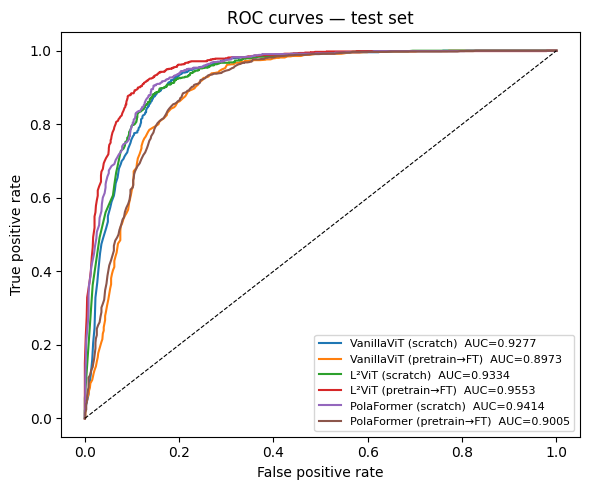

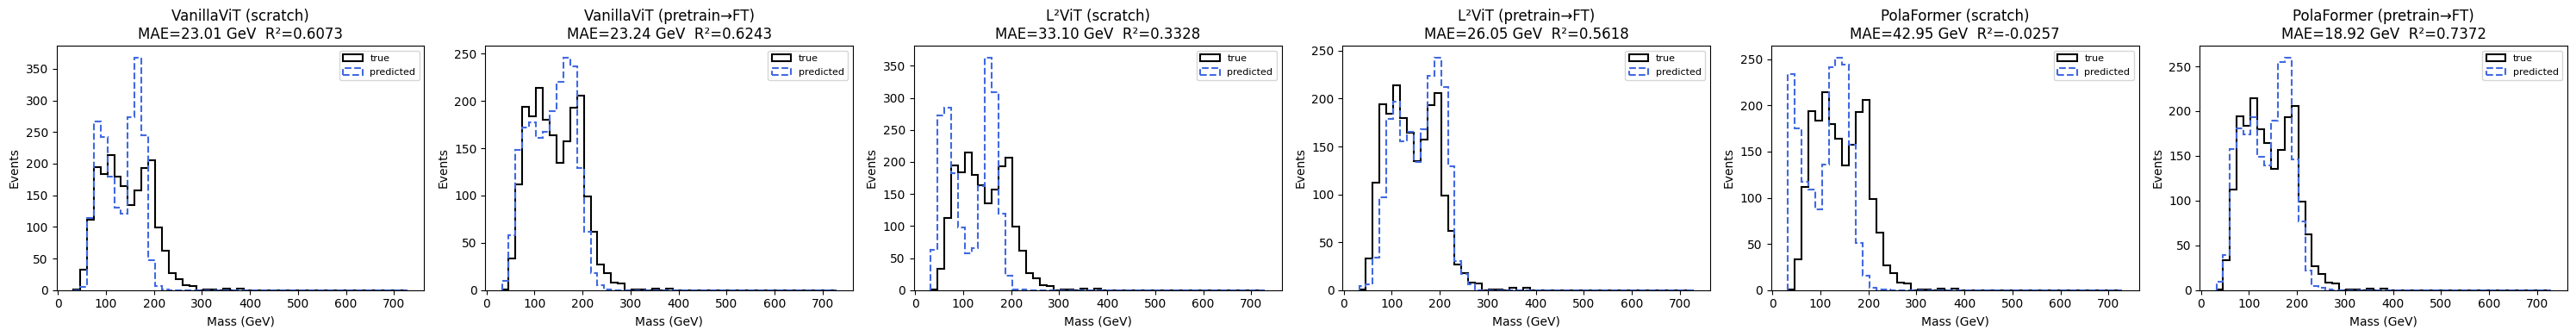

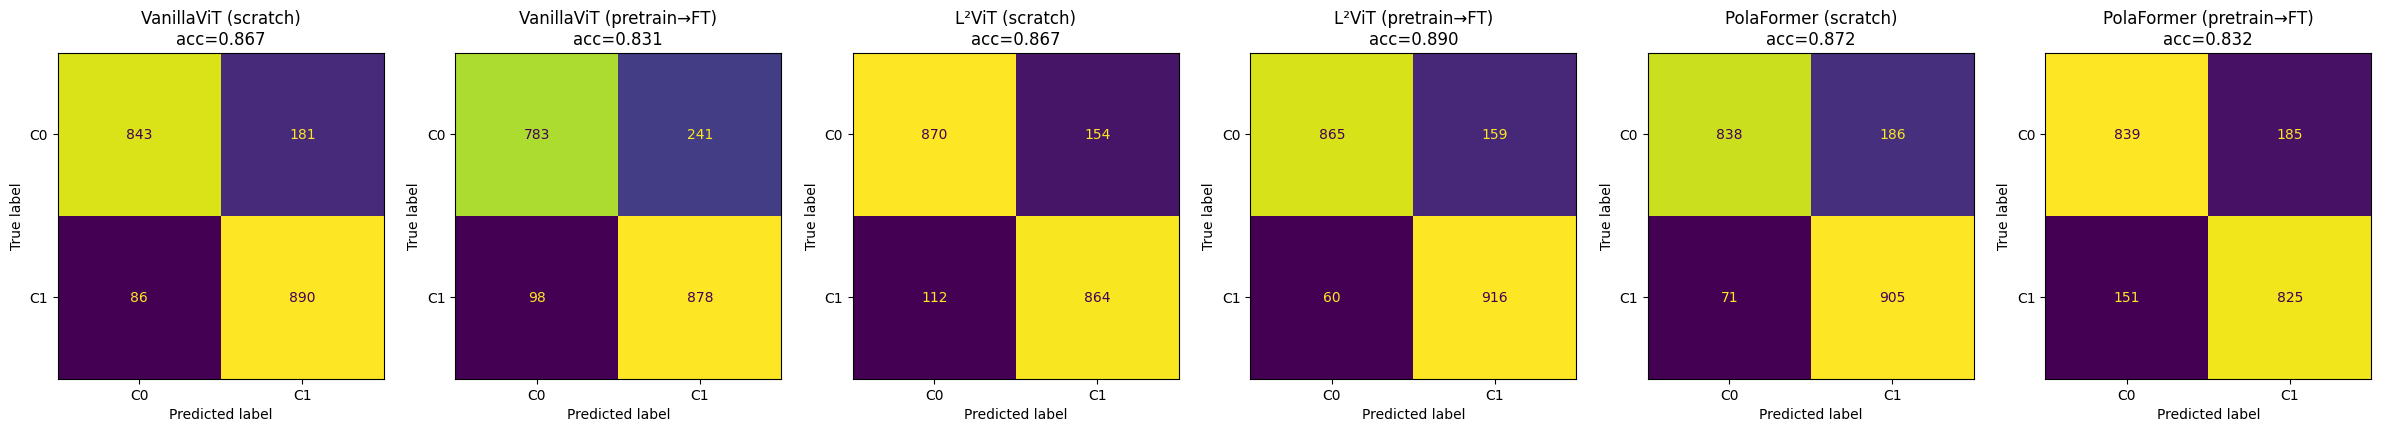


Model                             Acc    AUC  MAE (GeV)      R²
---------------------------------------------------------------
VanillaViT (scratch)           0.8665 0.9277      23.01  0.6073
VanillaViT (pretrain→FT)       0.8305 0.8973      23.24  0.6243
L²ViT (scratch)                0.8670 0.9334      33.10  0.3328
L²ViT (pretrain→FT)            0.8905 0.9553      26.05  0.5618
PolaFormer (scratch)           0.8715 0.9414      42.95 -0.0257
PolaFormer (pretrain→FT)       0.8320 0.9005      18.92  0.7372


### Markdown table

| Model | Acc | AUC | MAE (GeV) | R² |
|---|---|---|---|---|
| VanillaViT (scratch) | 0.8665 | 0.9277 | 23.01 | 0.6073 |
| VanillaViT (pretrain→FT) | 0.8305 | 0.8973 | 23.24 | 0.6243 |
| L²ViT (scratch) | 0.8670 | 0.9334 | 33.10 | 0.3328 |
| L²ViT (pretrain→FT) | 0.8905 | 0.9553 | 26.05 | 0.5618 |
| PolaFormer (scratch) | 0.8715 | 0.9414 | 42.95 | -0.0257 |
| PolaFormer (pretrain→FT) | 0.8320 | 0.9005 | 18.92 | 0.7372 |


In [11]:
# Cell 11: Evaluation — all checkpoints

from sklearn.metrics import (accuracy_score, roc_auc_score,
                              roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay)

ENCODER_MAP = {
    "vit_scratch":         lambda: VanillaViTEncoder(),
    "vit_finetune":        lambda: VanillaViTEncoder(),
    "l2vit_scratch":       lambda: L2ViTEncoder(use_lcm=True),
    "l2vit_nolcm_scratch": lambda: L2ViTEncoder(use_lcm=False),
    "l2vit_finetune":      lambda: L2ViTEncoder(use_lcm=True),
    "polaformer_scratch":  lambda: PolaFormerEncoder(use_lcm=True),
    "polaformer_finetune": lambda: PolaFormerEncoder(use_lcm=True),
}

DISPLAY_NAMES = {
    "vit_scratch":         "VanillaViT (scratch)",
    "vit_finetune":        "VanillaViT (pretrain→FT)",
    "l2vit_scratch":       "L²ViT (scratch)",
    "l2vit_nolcm_scratch": "L²ViT no-LCM (scratch)",
    "l2vit_finetune":      "L²ViT (pretrain→FT)",
    "polaformer_scratch":  "PolaFormer (scratch)",
    "polaformer_finetune": "PolaFormer (pretrain→FT)",
}


@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    labels, probs, cls_p, reg_p, reg_gt = [], [], [], [], []
    for x, yc, yr in loader:
        x = x.to(device)
        with autocast(device.type, enabled=USE_AMP, dtype=AMP_DTYPE):
            cl, ro = model(x)
        probs.append(F.softmax(cl, dim=1)[:, 1].cpu().float().numpy())
        labels.append(yc.numpy())
        cls_p.append(cl.argmax(1).cpu().numpy())
        reg_p.append(ro.cpu().float().numpy())
        reg_gt.append(yr.numpy())
    return (np.concatenate(labels), np.concatenate(probs),
            np.concatenate(cls_p),  np.concatenate(reg_p),
            np.concatenate(reg_gt))


def denorm_gev(y_norm):
    """Convert normalised [0,1] mass back to GeV."""
    return y_norm * (REG_MAX - REG_MIN) + REG_MIN


def reg_metrics_gev(y_true_gev, y_pred_gev):
    """MSE, MAE, R² all in GeV (or GeV²)."""
    mse    = float(np.mean((y_true_gev - y_pred_gev) ** 2))
    mae    = float(np.mean(np.abs(y_true_gev - y_pred_gev)))
    ss_res = float(np.sum((y_true_gev - y_pred_gev) ** 2))
    ss_tot = float(np.sum((y_true_gev - y_true_gev.mean()) ** 2))
    r2     = 1.0 - ss_res / (ss_tot + 1e-8)
    return mse, mae, r2


# ── Load all available checkpoints ───────────────────────────────────────────
results = {}   # key = experiment name, value = metrics dict

for exp_key, enc_factory in ENCODER_MAP.items():
    ckpt = WEIGHTS_DIR / f"model_{exp_key}.pt"
    if not ckpt.exists():
        continue
    print(f"Loading {exp_key} from {ckpt.name} ...", end=" ")
    enc = enc_factory().to(DEVICE)
    mdl = L2ViTDualHead(enc).to(DEVICE)
    mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE))

    labels, probs, cls_p, reg_norm, reg_gt_norm = collect_preds(
        mdl, test_loader, DEVICE)

    acc = float(accuracy_score(labels, cls_p))
    try:
        auc = float(roc_auc_score(labels, probs))
        fpr, tpr, _ = roc_curve(labels, probs)
    except ValueError:
        auc = float("nan")
        fpr = tpr = np.array([0.0, 1.0])

    if HAS_REGRESSION:
        reg_gev    = denorm_gev(reg_norm)
        reg_gt_gev = denorm_gev(reg_gt_norm)
        mse, mae_gev, r2 = reg_metrics_gev(reg_gt_gev, reg_gev)
    else:
        reg_gev = reg_gt_gev = np.zeros(len(labels))
        mse = mae_gev = r2 = float("nan")

    results[exp_key] = dict(
        labels=labels, probs=probs, cls_p=cls_p,
        reg_gev=reg_gev, reg_gt_gev=reg_gt_gev,
        acc=acc, auc=auc, fpr=fpr, tpr=tpr,
        mse=mse, mae_gev=mae_gev, r2=r2)
    print(f"acc={acc:.4f}  auc={auc:.4f}  mae={mae_gev:.2f} GeV")

if not results:
    print("No checkpoints found. Run Cell 9 first.")
else:
    # ── ROC curves ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    for key, res in results.items():
        ax.plot(res["fpr"], res["tpr"],
                label=f"{DISPLAY_NAMES[key]}  AUC={res['auc']:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title("ROC curves — test set")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Mass distribution: predicted vs true ─────────────────────────────────
    if HAS_REGRESSION:
        n_models = len(results)
        fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4),
                                  sharey=False)
        if n_models == 1:
            axes = [axes]
        bins = np.linspace(REG_MIN, REG_MAX, 50)
        for ax, (key, res) in zip(axes, results.items()):
            ax.hist(res["reg_gt_gev"], bins=bins, histtype="step",
                    label="true", color="black", lw=1.5)
            ax.hist(res["reg_gev"],    bins=bins, histtype="step",
                    label="predicted", color="royalblue", lw=1.5, linestyle="--")
            ax.set_xlabel("Mass (GeV)")
            ax.set_ylabel("Events")
            ax.set_title(f"{DISPLAY_NAMES[key]}\n"
                         f"MAE={res['mae_gev']:.2f} GeV  R²={res['r2']:.4f}")
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(PROJECT_DIR / "mass_distributions.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    # ── Confusion matrices ────────────────────────────────────────────────────
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    if n_models == 1:
        axes = [axes]
    for ax, (key, res) in zip(axes, results.items()):
        cm = confusion_matrix(res["labels"], res["cls_p"])
        ConfusionMatrixDisplay(cm, display_labels=[f"C{i}"
                               for i in range(NUM_CLASSES)]).plot(
            ax=ax, colorbar=False)
        ax.set_title(f"{DISPLAY_NAMES[key]}\nacc={res['acc']:.3f}")
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "confusion_matrices.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary table (markdown) ──────────────────────────────────────────────
    header = f"{'Model':<30} {'Acc':>6} {'AUC':>6} {'MAE (GeV)':>10} {'R²':>7}"
    print("\n" + header)
    print("-" * len(header))
    for key, res in results.items():
        mae_str = f"{res['mae_gev']:>10.2f}" if HAS_REGRESSION else f"{'—':>10}"
        r2_str  = f"{res['r2']:>7.4f}"       if HAS_REGRESSION else f"{'—':>7}"
        print(f"{DISPLAY_NAMES[key]:<30} {res['acc']:>6.4f} {res['auc']:>6.4f} "
              f"{mae_str} {r2_str}")

    # markdown version for copy-paste into proposal
    print("\n\n### Markdown table\n")
    print("| Model | Acc | AUC | MAE (GeV) | R² |")
    print("|---|---|---|---|---|")
    for key, res in results.items():
        mae_str = f"{res['mae_gev']:.2f}" if HAS_REGRESSION else "—"
        r2_str  = f"{res['r2']:.4f}"      if HAS_REGRESSION else "—"
        print(f"| {DISPLAY_NAMES[key]} | {res['acc']:.4f} | {res['auc']:.4f} "
              f"| {mae_str} | {r2_str} |")

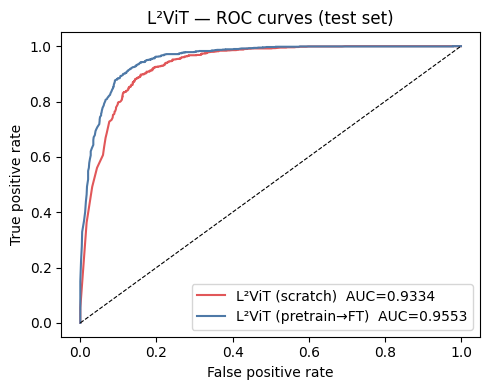

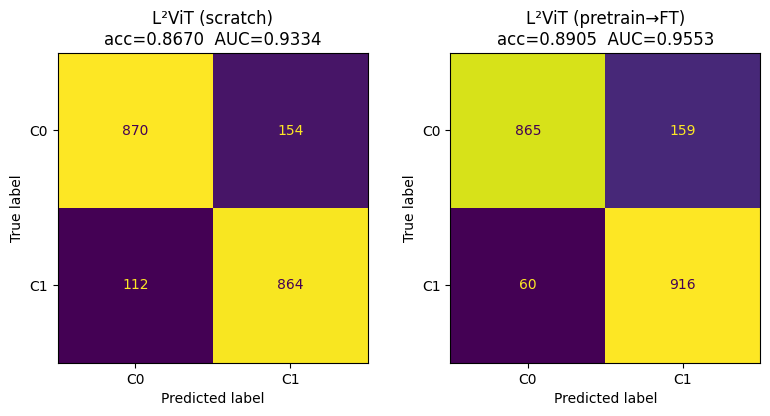

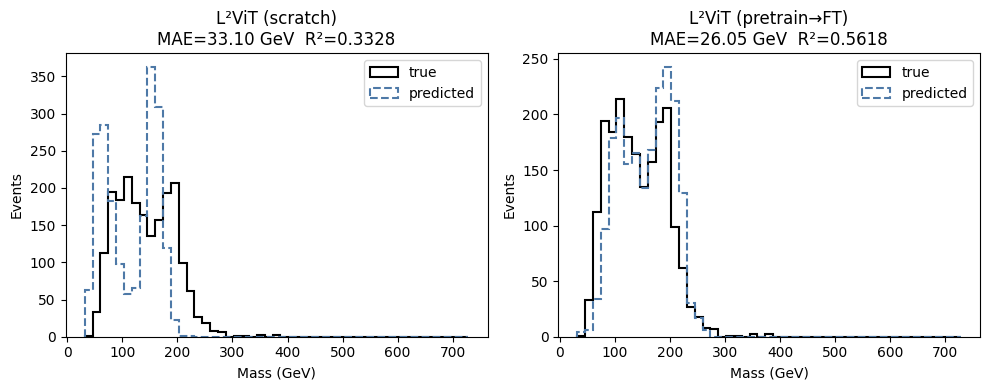


L²ViT Test Results
Model                            Acc     AUC   MAE (GeV)       R²
-----------------------------------------------------------------
L²ViT (scratch)               0.8670  0.9334       33.10   0.3328
L²ViT (pretrain→FT)           0.8905  0.9553       26.05   0.5618
-----------------------------------------------------------------
Δ (finetune − scratch)       +0.0235 +0.0218       -7.06  +0.2290

| Model | Acc | AUC | MAE (GeV) | R² |
|---|---|---|---|---|
| L²ViT (scratch) | 0.8670 | 0.9334 | 33.10 | 0.3328 |
| L²ViT (pretrain→FT) | 0.8905 | 0.9553 | 26.05 | 0.5618 |


In [12]:
# Cell 12: L²ViT — Scratch vs Pretrain→Finetune (Task 2h)
# Run Cell 11 first to populate `results`.

L2VIT_KEYS = ["l2vit_scratch", "l2vit_finetune"]
l2vit_res = {k: results[k] for k in L2VIT_KEYS if k in results}

if len(l2vit_res) < 2:
    print("Missing L²ViT checkpoints — run Cell 11 first.")
else:
    DASH = "—"

    # ROC curves
    fig, ax = plt.subplots(figsize=(5, 4))
    for (key, res), color in zip(l2vit_res.items(), ["#e15759", "#4e79a7"]):
        name, auc = DISPLAY_NAMES[key], res["auc"]
        ax.plot(res["fpr"], res["tpr"], color=color, label=name + "  AUC=" + f"{auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("L²ViT — ROC curves (test set)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "roc_l2vit_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, (key, res) in zip(axes, l2vit_res.items()):
        name, acc, auc = DISPLAY_NAMES[key], res["acc"], res["auc"]
        cm = confusion_matrix(res["labels"], res["cls_p"])
        ConfusionMatrixDisplay(cm, display_labels=["C0", "C1"]).plot(ax=ax, colorbar=False)
        ax.set_title(name + "\nacc=" + f"{acc:.4f}  AUC={auc:.4f}")
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "cm_l2vit_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Mass distributions
    if HAS_REGRESSION:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        bins = np.linspace(REG_MIN, REG_MAX, 50)
        for ax, (key, res) in zip(axes, l2vit_res.items()):
            name = DISPLAY_NAMES[key]
            mae_gev, r2 = res["mae_gev"], res["r2"]
            ax.hist(res["reg_gt_gev"], bins=bins, histtype="step", label="true",      color="black",   lw=1.5)
            ax.hist(res["reg_gev"],    bins=bins, histtype="step", label="predicted",  color="#4e79a7", lw=1.5, linestyle="--")
            ax.set_xlabel("Mass (GeV)")
            ax.set_ylabel("Events")
            ax.set_title(name + "\nMAE=" + f"{mae_gev:.2f} GeV  R²={r2:.4f}")
            ax.legend()
        plt.tight_layout()
        plt.savefig(PROJECT_DIR / "mass_l2vit_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()

    # Summary table
    s, ft = l2vit_res["l2vit_scratch"], l2vit_res["l2vit_finetune"]
    print("\nL²ViT Test Results")
    print("{:<28} {:>7} {:>7} {:>11} {:>8}".format("Model", "Acc", "AUC", "MAE (GeV)", "R²"))
    print("-" * 65)
    for key, res in l2vit_res.items():
        mae_s = "{:>11.2f}".format(res["mae_gev"]) if HAS_REGRESSION else "{:>11}".format(DASH)
        r2_s  = "{:>8.4f}".format(res["r2"])       if HAS_REGRESSION else "{:>8}".format(DASH)
        print("{:<28} {:>7.4f} {:>7.4f} {} {}".format(
            DISPLAY_NAMES[key], res["acc"], res["auc"], mae_s, r2_s))
    if HAS_REGRESSION:
        print("-" * 65)
        print("{:<28} {:>+7.4f} {:>+7.4f} {:>+11.2f} {:>+8.4f}".format(
            "Δ (finetune − scratch)",
            ft["acc"] - s["acc"], ft["auc"] - s["auc"],
            ft["mae_gev"] - s["mae_gev"], ft["r2"] - s["r2"]))
    print("\n| Model | Acc | AUC | MAE (GeV) | R² |")
    print("|---|---|---|---|---|")
    for key, res in l2vit_res.items():
        mae_s = "{:.2f}".format(res["mae_gev"]) if HAS_REGRESSION else DASH
        r2_s  = "{:.4f}".format(res["r2"])      if HAS_REGRESSION else DASH
        print("| {} | {:.4f} | {:.4f} | {} | {} |".format(
            DISPLAY_NAMES[key], res["acc"], res["auc"], mae_s, r2_s))


In [10]:
import wandb
wandb.login()

True